In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# %run /content/AIFFEL_final_pjt_book-recommendation-agent/src/profiling/user_profiling_demo_jc.ipynb
%run /content/AIFFEL_final_pjt_book-recommendation-agent/src/profiling/advanced_profiling_demo.ipynb

Exception: File `'/content/AIFFEL_final_pjt_book-recommendation-agent/src/profiling/user_profiling_demo_jc.ipynb.py'` not found.

In [ ]:
# %run /content/AIFFEL_final_pjt_book-recommendation-agent/src/rag/simple_rag/simple_rag.ipynb
%run /content/AIFFEL_final_pjt_book-recommendation-agent/src/rag/query_transformations/query_transformations_rag.ipynb

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 7.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

In [ ]:
%run /content/AIFFEL_final_pjt_book-recommendation-agent/src/tools/api_tool_calling.ipynb

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_7372/1090797661.py:41: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(


In [ ]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, END


graph = StateGraph(GraphState)

# 프로파일링 노드
graph.add_node("generate_slot_question",  nodes["generate_slot_question"])
graph.add_node("process_slot_answer",     nodes["process_slot_answer"])
graph.add_node("search_similar_profiles", nodes["search_similar_profiles"])
graph.add_node("process_match_confirm",   nodes["process_match_confirm"])
graph.add_node("ask_book_experience",     nodes["ask_book_experience"])
graph.add_node("process_book_experience", nodes["process_book_experience"])
graph.add_node("generate_summary",        nodes["generate_summary"])
graph.add_node("perform_reflection",      nodes["perform_reflection"])

# RAG 노드
graph.add_node("extract_genre",       extract_genre_node)
graph.add_node("query_transform_rag", query_transform_rag_node)
graph.add_node("rag_llm",             rag_llm_node)


# Tool Calling 노드
graph.add_node("api_tool_calling", api_tool_calling_node)

# 프로파일링 엣지
graph.set_entry_point("generate_slot_question")
graph.add_edge("generate_slot_question", "process_slot_answer")
graph.add_conditional_edges("process_slot_answer", route_after_slot_processing,
    {"generate_slot_question": "generate_slot_question",
     "search_similar_profiles": "search_similar_profiles",
     "ask_book_experience":     "ask_book_experience"})
graph.add_conditional_edges("search_similar_profiles", route_after_similar_search,
    {"process_match_confirm":   "process_match_confirm",
     "generate_slot_question":  "generate_slot_question"})
graph.add_conditional_edges("process_match_confirm", route_after_match_confirm,
    {"ask_book_experience":     "ask_book_experience",
     "generate_slot_question":  "generate_slot_question"})
graph.add_edge("ask_book_experience",    "process_book_experience")
graph.add_conditional_edges("process_book_experience", route_after_book_experience,
    {"ask_book_experience":  "ask_book_experience",
     "generate_summary":     "generate_summary"})
graph.add_edge("generate_summary", "perform_reflection")

# 연결 지점 (profiling -> rag)
graph.add_edge("perform_reflection", "extract_genre")

# RAG 엣지
graph.add_edge("extract_genre",       "query_transform_rag")
graph.add_edge("query_transform_rag", "rag_llm")

# 연결 지점 (memory -> tool calling)
graph.add_edge("rag_llm", "api_tool_calling")
graph.add_edge("api_tool_calling",    END)


app = graph.compile(
    checkpointer=MemorySaver(),
    interrupt_before=[
        "process_slot_answer",
        "process_match_confirm",
        "process_book_experience",
    ],
)

In [ ]:
# ── 의존성 초기화 ──




initial_state = create_initial_state(session_id)

In [ ]:
# ============================================================
# 초기 상태
# ============================================================
import uuid
from langchain_openai import ChatOpenAI

llm          = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)
memory_store = MemoryStore(persist_directory="./chroma_db")

session_id = str(uuid.uuid4())[:8]


initial_state = {
    # 메모리 필드
    "messages": [],
    "session_id": session_id,
    "phase": Phase.SLOT_FILLING,
    "turn_count": 0,
    "user_profile": UserProfile(),
    "current_slot": "reading_goal",
    "similar_profiles": None,
    "matched_profile_id": None,
    "book_experiences": [],
    "asked_book_experience": False,
    "summary": "",
    "reflection": "",
    "links": [],
    "ai_response": "",

    # RAG 필드 추가
    "retrieved_books": [],
    "recommendations": [],
    "genre_filter": [],

    # Tool Calling
    "availability_results" : None,
}

config     = {"configurable": {"thread_id": f"thread_{session_id}"}}

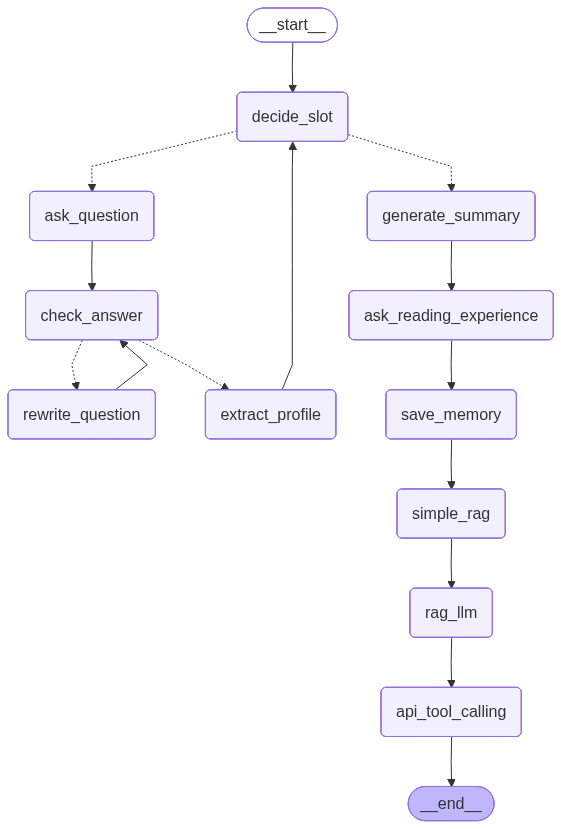

In [ ]:
app

In [ ]:
# # ============================================================
# # 최초 graph 실행
# # ============================================================

# result = app.invoke(initial_state, config=config)

# # ============================================================
# # Multi-turn Loop
# # ============================================================

# while True:

#     if "__interrupt__" in result:

#         interrupt_obj = result["__interrupt__"][0]
#         question = interrupt_obj.value
#         print(f"\nAI: {question}")

#         user_input = input("\nUSER: ")

#         result = app.invoke(
#             Command(resume=user_input),
#             config=config
#         )

#     else:

#         print("\n=== USER PROFILING FINISHED ===\n")

#         print("PROFILE:")
#         print(json.dumps(result["profile"], ensure_ascii=False, indent=2))

#         print("\nSUMMARY:")
#         print(result["summary"])

#         print("\n=== BOOK LIST ===\n")
#         try:
#             print(json.dumps(result["recommendations"], ensure_ascii=False, indent=2))
#         except:
#             print(result["recommendations"])

#         print("\n=== 추천 결과 ===\n")
#         print(result["messages"][-1].content)

#         break


AI: 현재 독서를 통해 어떤 목표를 이루고 싶으신가요?

USER: 철학책을 공부하고 싶어

AI: 최근에 읽었던 책 중에서 가장 흥미로웠던 장르는 무엇인가요?

USER: 실존주의 철학

AI: 책을 읽을 때, 주로 어떤 방식으로 내용을 이해하고 흡수하는 것을 선호하시나요? 예를 들어, 깊이 있는 분석을 좋아하시나요, 아니면 빠르게 전체적인 흐름을 파악하는 것을 선호하시나요?

USER: 깊이 있는 분석을 중시해

AI: 어떤 난이도의 책을 선호하시나요? 초급, 중급, 고급 중에서 선택해 주실 수 있나요?

USER: 의미있는 삶을 알려주는 책을 몰입해서 읽는 편이야. 그리고 도전적인 수준의 책을 좋아해

AI: 최근에 어떤 감정이나 상황에서 책을 읽고 싶으신가요?

USER: 조용히, 혼자만의 상황에서 책을 읽고 싶어

AI: 이전에 실존주의 철학과 관련된 책을 읽어본 적이 있으신가요? 읽으셨다면 어떤 책이었고, 그 책에 대한 감상이나 소감은 어떠셨나요?

USER: 아니 읽어본적 없어

▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📡 [ISBN + 표지 URL 검색	API 통신 로그]
👉 실제 호출된 URL: https://openapi.naver.com/v1/search/book.json?query=%EC%83%9D%EC%A1%B4%EB%A1%A0&display=1
▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📡 [ISBN + 표지 URL 검색	API 통신 로그]
👉 실제 호출된 URL: https://openapi.naver.com/v1/search/book.json?query=%EC%9D%B8%EA%B2%A9%EC%9D%98+%EC%B2%A0%ED%95%99+%EC%B2%A0%ED%95%99%EC%9D%98+%EC%9D%B8%EA%B2%A9&display=1
▲